# Experiment 2: Local Search Pipeline Analysis

This notebook analyzes the results of Experiment 2. The goal is to determine which combinations of start partitions and local-search pipelines perform best for different graph classes, density regimes, and graph sizes.

The analysis focuses on three questions:

1. Which pipeline achieves the best final density?
2. Which start partition is most useful?
3. Which local-search steps contribute meaningful improvements?

In [89]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

## Best-Run Aggregation

- each local-search configuration was executed multiple times with different random seed to estimate the influence of randimization on solution quality
- for the main analysis only the best run is retained

In [199]:
RESULTS_DIR = Path("../results/experiment2_small_powerlaw_dense")

raw = pd.read_csv(RESULTS_DIR / "raw_results.csv")

best_runs = (
    raw.sort_values("final_density", ascending=False)
    .groupby(
        ["instance", "start_partition", "pipeline"],
        as_index=False
    )
    .first()
)

In [139]:
def subset(
        df: pd.DataFrame,
        size_class: str,
        graph_type: str,
        regime: str,
) -> pd.DataFrame:
    return df[
        (df["size_class"] == size_class)
        & (df["graph_type"] == graph_type)
        & (df["regime"] == regime)
        ].copy()

## Power-law instances

We first restrict the analysis to power-law graphs.

### Analysis: Influence of the startpartition

- evaluate how strongly the choice of the initial partition affects the final solution quality after local search

In [200]:
#current = subset(best_runs, "small", "powerlaw", "dense")
current = best_runs

start_partition_ranking = (
    current
    .groupby("start_partition")
    .agg(
        mean_start_density=("start_density", "mean"),
        mean_final_density=("final_density", "mean"),
        mean_absolute_improvement=("absolute_improvement", "mean"),
        mean_relative_improvement=("relative_improvement", "mean"),
        improvement_rate=("improved", "mean"),
        mean_num_moves=("num_moves", "mean"),
        mean_total_runtime=("total_runtime", "mean"),
        mean_start_num_clusters=("start_num_clusters", "mean"),
        mean_final_num_clusters=("final_num_clusters", "mean"),
    )
    .reset_index()
    .sort_values("mean_final_density", ascending=False)
)

start_partition_ranking

,start_partition,mean_start_density,mean_final_density,mean_absolute_improvement,mean_relative_improvement,improvement_rate,mean_num_moves,mean_total_runtime,mean_start_num_clusters,mean_final_num_clusters
2,kapoce,43.022242,44.640922,1.618683,0.038831,0.99680,234.93840,0.260504,64.556,57.90704
1,high_degree_product_matching,29.046000,43.405350,14.359350,0.503012,1.00000,293.82160,0.269441,97.816,57.00448
4,matching,30.436000,43.402613,12.966613,0.433514,1.00000,287.34048,0.252455,95.036,57.76080
0,high_degree_first_matching,29.046000,43.401215,14.355215,0.502872,1.00000,293.94432,0.270014,97.816,56.97904
3,leiden_mdgp,41.138266,43.280015,2.141748,0.052235,0.77856,238.94720,0.171581,60.700,57.74496
5,maximum_matching,38.846000,42.749224,3.903224,0.106244,0.96048,245.13504,0.190126,78.216,65.45184
6,singleton,0.000000,42.718979,42.718979,0.000000,1.00000,361.12464,0.383176,155.908,55.20752


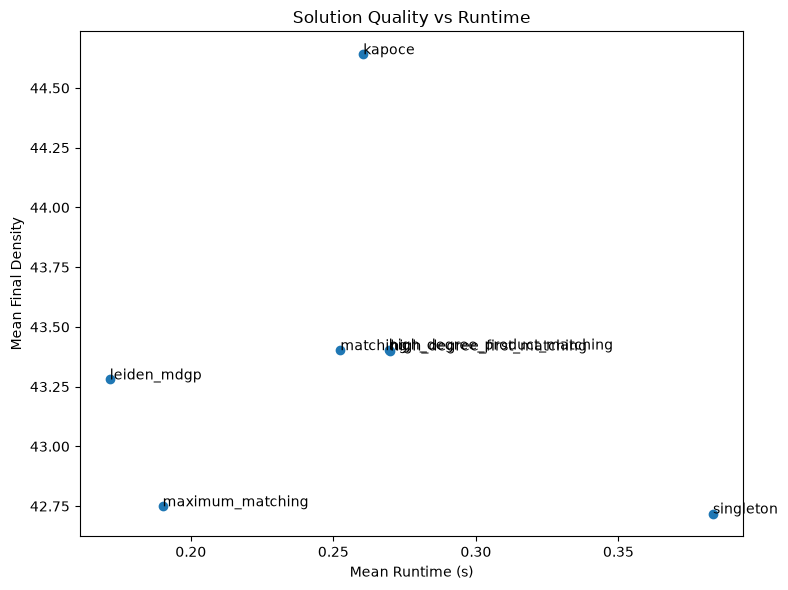

In [201]:
plt.figure(figsize=(8, 6))

plt.scatter(
    start_partition_ranking["mean_total_runtime"],
    start_partition_ranking["mean_final_density"]
)

for _, row in start_partition_ranking.iterrows():
    plt.annotate(
        row["start_partition"],
        (
            row["mean_total_runtime"],
            row["mean_final_density"]
        )
    )

plt.xlabel("Mean Runtime (s)")
plt.ylabel("Mean Final Density")
plt.title("Solution Quality vs Runtime")

plt.tight_layout()
plt.show()

### Analysis: Best achievable solution per start partition

- evaluate the maximum solution quality that can be achieved from each start partition
- instead of averaging over all best_runs, only the best run for every ``(instance, start_partition)``pair is retained

In [187]:
best_per_instance = (
    current
    .sort_values("final_density", ascending=False)
    .groupby(
        ["instance", "start_partition"],
        as_index=False
    )
    .first()
)
best_per_start_partition = (
    best_per_instance
    .groupby("start_partition")
    .agg(
        mean_best_density=("final_density", "mean")
    )
    .sort_values("mean_best_density", ascending=False)
)

best_per_start_partition

,mean_best_density
start_partition,
maximum_matching,42.378872
high_degree_first_matching,42.351270
matching,42.350068
high_degree_product_matching,42.340135
singleton,42.335202
kapoce,42.294806
leiden_mdgp,42.285535


#### Results
- the differences almost disappear
- maximum matching becomes the strongest start partition
- interpretation:
    - average-case analysis suggested: good start partitions lead to good final solutions
    - best-run analysis suggests: most start partitions are capable of reaching nearly identical high-quality solutions

### Analysis: Pipeline Ranking

- Evaluate which local-search pipelines produce the highest final partition density

In [188]:
best_pipeline_ranking = (
    current
    .groupby("pipeline")
    .agg(
        mean_final_density=("final_density", "mean")
    )
    .sort_values("mean_final_density", ascending=False)
)

best_pipeline_ranking

,mean_final_density
pipeline,
"move_plateau,merge_best,bridge_split,move_plateau,move_best",42.222450
"move_plateau,merge_best,bridge_split,move_plateau",42.216630
"move_plateau,bridge_split,move_plateau,move_best",42.216126
"move_plateau,bridge_split,merge_best,move_plateau",42.215527
"move_best,move_plateau",41.971744
"move_plateau,bridge_split,move_best",41.969126
"move_plateau,merge_best",41.966802
"move_plateau,split_min_cut,move_best",41.961202
"move_plateau,bridge_split",41.957516


##### Research Notes

Questions for further investigation:

- Why is `move_plateau` substantially stronger than both `move_first` and `move_best`?
- Does `move_plateau` consistently dominate on all graph classes or only on dense power-law graphs?
- Are merge operators useful only after plateau search has converged?
- Can bridge-based diversification create additional opportunities for plateau search?
- Is the observed advantage of the best pipeline statistically significant or merely noise?
- Would repeated applications of `move_plateau` outperform longer heterogeneous pipelines?

### Analysis: Start Partition x Pipeline Combinations

- identify the strongest combinations of start partitions and local-search pipelines

In [202]:
combo_ranking = (
    current
    .groupby(["start_partition", "pipeline"])
    .agg(
        mean_final_density=("final_density", "mean"),
        mean_relative_improvement=("relative_improvement", "mean"),
        improvement_rate=("improved", "mean"),
    )
    .sort_values("mean_final_density", ascending=False)
)

combo_ranking

mean_final_density  \
start_partition              pipeline                                                                 
maximum_matching             move_plateau,merge_best,bridge_split,move_plate...           45.086336   
                             move_plateau,merge_best,bridge_split,move_plateau            45.076601   
                             move_plateau,bridge_split,merge_best,move_plateau            45.072667   
                             move_plateau,bridge_split,move_plateau,move_best             45.067265   
                             merge_first,move_plateau                                     45.049268   
...                                                                                             ...   
high_degree_first_matching   merge_best                                                   38.488634   
matching                     merge_first                                                  37.156912   
high_degree_product_matching merge_first                                                  36.422536   
high_degree_first_matching   merge_first                                                  36.412944   
singleton                    merge_first                                                  29.526024   

                                                                                 mean_relative_improvement  \
start_partition              pipeline                                                                        
maximum_matching             move_plateau,merge_best,bridge_split,move_plate...                   0.167284   
                             move_plateau,merge_best,bridge_split,move_plateau                    0.167211   
                             move_plateau,bridge_split,merge_best,move_plateau                    0.166969   
                             move_plateau,bridge_split,move_plateau,move_best                     0.166842   
                             merge_first,move_plateau                                             0.166578   
...                                                                                                    ...   
high_degree_first_matching   merge_best                                                           0.332776   
matching                     merge_first                                                          0.228231   
high_degree_product_matching merge_first                                                          0.262790   
high_degree_first_matching   merge_first                                                          0.262123   
singleton                    merge_first                                                          0.000000   

                                                                                 improvement_rate  
start_partition              pipeline                                                              
maximum_matching             move_plateau,merge_best,bridge_split,move_plate...               1.0  
                             move_plateau,merge_best,bridge_split,move_plateau                1.0  
                             move_plateau,bridge_split,merge_best,move_plateau                1.0  
                             move_plateau,bridge_split,move_plateau,move_best                 1.0  
                             merge_first,move_plateau                                         1.0  
...                                                                                           ...  
high_degree_first_matching   merge_best                                                       1.0  
matching                     merge_first                                                      1.0  
high_degree_product_matching merge_first                                                      1.0  
high_degree_first_matching   merge_first                                                      1.0  
singleton                    merge_first                                                      1.0  

[175 rows

In [193]:
pipeline_ranking = (
    current
    .groupby("pipeline")
    .agg(
        mean_density=("final_density", "mean"),
        mean_runtime=("total_runtime", "mean"),
        mean_moves=("num_moves", "mean"),
        win_rate=("is_best", "mean"),
    )
    .sort_values("mean_density", ascending=False)
)

pipeline_ranking

,mean_density,mean_runtime,mean_moves,win_rate
pipeline,,,,
"move_plateau,merge_best,bridge_split,move_plateau,move_best",42.222450,0.900346,633.089143,0.251429
"move_plateau,merge_best,bridge_split,move_plateau",42.216630,0.842699,632.522286,0.231429
"move_plateau,bridge_split,move_plateau,move_best",42.216126,0.909100,633.876571,0.241143
"move_plateau,bridge_split,merge_best,move_plateau",42.215527,0.896724,634.440000,0.249714
"move_best,move_plateau",41.971744,0.541840,339.826286,0.102286
"move_plateau,bridge_split,move_best",41.969126,0.400526,336.580571,0.118286
"move_plateau,merge_best",41.966802,0.352840,336.319429,0.101143
"move_plateau,split_min_cut,move_best",41.961202,0.387172,336.700571,0.106286
"move_plateau,bridge_split",41.957516,0.366214,335.298857,0.105143


In [194]:
best_per_instance = (
    current
    .sort_values("final_density", ascending=False)
    .groupby("instance")
    .first()
)

best_per_instance.groupby("pipeline").size().sort_values(ascending=False)

pipeline
move_plateau,merge_best,bridge_split,move_plateau,move_best    48
move_plateau,bridge_split,move_plateau,move_best               41
move_plateau,bridge_split,merge_best,move_plateau              30
move_plateau,merge_best,bridge_split,move_plateau              29
move_best,move_plateau                                         13
move_plateau                                                   13
merge_first,move_plateau,bridge_split,move_best                11
move_plateau,bridge_split,move_best                            10
move_plateau,split_min_cut,move_best                            9
merge_best,move_plateau,bridge_split,move_best                  8
merge_first,move_plateau                                        8
move_plateau,bridge_split                                       4
move_plateau,merge_best                                         4
move_best,merge_best                                            3
merge_best,move_first                                           3
m

In [195]:
winner_per_instance = (
    current
    .sort_values("final_density", ascending=False)
    .groupby("instance")
    .first()
)

winner_per_instance.groupby(
    ["start_partition", "pipeline"]
).size().sort_values(ascending=False)

start_partition               pipeline                                                   
kapoce                        move_plateau,merge_best,bridge_split,move_plateau,move_best    11
high_degree_first_matching    move_plateau,bridge_split,move_plateau,move_best               10
high_degree_product_matching  move_plateau,merge_best,bridge_split,move_plateau,move_best     9
maximum_matching              move_plateau,bridge_split,merge_best,move_plateau               9
                              move_plateau,bridge_split,move_plateau,move_best                7
                                                                                             ..
singleton                     merge_best,move_plateau,bridge_split,move_best                  1
                              move_plateau,bridge_split,merge_best,move_plateau               1
                              move_plateau                                                    1
                              move_best,move_p

In [147]:
ranked = best_runs.copy()

ranked["instance_rank"] = (
    ranked.groupby("instance")["final_density"]
    .rank(method="min", ascending=False)
)

top3_per_instance = ranked[ranked["instance_rank"] <= 3].copy()

top3_summary = (
    top3_per_instance
    .groupby(["start_partition", "pipeline"])
    .agg(
        top3_count=("instance", "count"),
        mean_top3_rank=("instance_rank", "mean"),
        mean_top3_density=("final_density", "mean"),
    )
    .reset_index()
    .sort_values(["top3_count", "mean_top3_rank"], ascending=[False, True])
)

top3_summary

,start_partition,pipeline,top3_count,mean_top3_rank,mean_top3_density
91,maximum_matching,"move_plateau,merge_best,bridge_split,move_plateau",77,1.441558,39.614504
92,maximum_matching,"move_plateau,merge_best,bridge_split,move_plat...",76,1.631579,43.080707
82,maximum_matching,"merge_first,move_plateau",69,1.449275,38.808459
87,maximum_matching,"move_plateau,bridge_split,merge_best,move_plateau",68,1.661765,42.341178
89,maximum_matching,"move_plateau,bridge_split,move_plateau,move_best",65,1.600000,41.678205
...,...,...,...,...,...
35,kapoce,"merge_first,move_first",1,3.000000,55.416700
38,kapoce,move_best,1,3.000000,55.416700
39,kapoce,"move_best,merge_best",1,3.000000,55.416700
40,kapoce,"move_best,merge_best,bridge_split,move_best",1,3.000000,55.416700


In [190]:
RESULTS_DIR = Path("../results/experiment2_small_er_sparse_final")

raw = pd.read_csv(RESULTS_DIR / "raw_results.csv")
step_summary = pd.read_csv(RESULTS_DIR / "step_summary.csv")

best_runs = (
    raw.sort_values("final_density", ascending=False)
    .groupby(
        ["instance", "start_partition", "pipeline"],
        as_index=False
    )
    .first()
)

In [191]:
winner_per_instance = (
    best_runs
    .sort_values("final_density", ascending=False)
    .groupby("instance")
    .first()
)

winner_per_instance.groupby(
    ["start_partition", "pipeline"]
).size().sort_values(ascending=False)

start_partition   pipeline                              
maximum_matching  move_plateau,move_plateau,move_plateau    80
                  move_plateau,move_plateau                 43
                  move_plateau,merge_first,move_plateau     38
                  move_plateau,merge_best,move_plateau      37
                  move_plateau,move_first,move_plateau      30
                  move_plateau                              10
                  merge_best,move_plateau                    8
                  merge_first,move_plateau                   4
dtype: int64

In [182]:
ranked = best_runs.copy()

ranked["instance_rank"] = (
    ranked.groupby("instance")["final_density"]
    .rank(method="min", ascending=False)
)

top3_per_instance = ranked[ranked["instance_rank"] <= 3].copy()

top3_summary = (
    top3_per_instance
    .groupby(["start_partition", "pipeline"])
    .agg(
        top3_count=("instance", "count"),
        mean_top3_rank=("instance_rank", "mean"),
        mean_top3_density=("final_density", "mean"),
    )
    .reset_index()
    .sort_values(["top3_count", "mean_top3_rank"], ascending=[False, True])
)

top3_summary

,start_partition,pipeline,top3_count,mean_top3_rank,mean_top3_density
7,maximum_matching,"move_plateau,move_plateau,move_plateau",214,1.401869,39.275156
3,maximum_matching,"move_plateau,merge_best,move_plateau",200,1.410000,39.408086
5,maximum_matching,"move_plateau,move_first,move_plateau",200,1.460000,39.384332
6,maximum_matching,"move_plateau,move_plateau",198,1.459596,38.980558
4,maximum_matching,"move_plateau,merge_first,move_plateau",188,1.484043,39.417913
2,maximum_matching,move_plateau,138,1.463768,34.467154
0,maximum_matching,"merge_best,move_plateau",134,1.492537,34.469657
1,maximum_matching,"merge_first,move_plateau",126,1.396825,33.794846


In [183]:
pipeline = "move_plateau,move_plateau,move_plateau"

pipeline_steps = step_summary[
    (step_summary["pipeline"] == pipeline)
    ].copy()

pipeline_steps

,phase,size_class,graph_type,regime,start_partition,pipeline,step_index,step_name,observations,mean_score_before,...,mean_absolute_improvement,mean_relative_improvement,active_rate,mean_num_moves,median_num_moves,mean_num_passes,median_num_passes,mean_runtime,mean_num_clusters_before,mean_num_clusters_after
16,small_powerlaw,small,powerlaw,sparse,maximum_matching,"move_plateau,move_plateau,move_plateau",0,move_plateau,2500,36.9640,...,3.3640,0.0927,1.0000,320.6628,304.0,27.1384,24.0,0.3162,75.8200,59.9616
17,small_powerlaw,small,powerlaw,sparse,maximum_matching,"move_plateau,move_plateau,move_plateau",1,move_plateau,2500,40.3280,...,0.0814,0.0017,0.9964,299.7080,286.0,38.6612,34.0,0.4461,59.9616,59.5948
18,small_powerlaw,small,powerlaw,sparse,maximum_matching,"move_plateau,move_plateau,move_plateau",2,move_plateau,2500,40.4093,...,0.0167,0.0003,0.9948,299.0012,286.0,40.7504,36.0,0.4680,59.5948,59.5272
